## Energy Price Pass-Through to Core Inflation in the Euro Area: Evidence from Pre- and Post-2021

This notebook investigates whether changes in energy prices, measured by the Brent crude oil price, affect core inflation in the euro area and whether this relationship changed after the post-2021 inflation episode.

Core inflation is defined as the HICP excluding energy and food (TOT_X_NRG_FOOD, EA20) and is used as a measure of underlying price pressure. We compare two periods, 2015 to 2019 and 2021 to 2024, while excluding 2020 due to pandemic-related disruptions.

Using cross-correlation analysis and regression models implemented in Python, we test whether the pass-through from energy prices to core inflation differs between the two periods.

We focus on short-term pass-through. A full analysis of medium- and long-term dynamics would require a larger sample and a more comprehensive model such as a VAR framework.

The results suggest that the direct short term pass-through from energy prices to core inflation was small even before 2021 and is no longer detectable in the post-shock period. The elevated level of core inflation after 2021 appears to reflect other drivers, as the pass-through coefficient does not differ significantly between the two periods.

We begin by importing the modules we plan to use.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.stattools import ccf as sm_ccf
from fredapi import Fred

Brent crude oil is widely used as a global benchmark for oil prices, particularly relevant for Europe. While it does not directly represent consumer energy prices, it serves as a standard proxy in macroeconomic studies. We obtain Brent crude oil prices from the FRED database (MCOILBRENTEU), measured in euros per barrel. Before running the notebook, set your FRED API key (free at fred.stlouisfed.org) as an environment variable (set FRED_API_KEY=yourkey (Windows) or export FRED_API_KEY=yourkey (Mac/Linux)).

In [14]:
fred = Fred(api_key=os.environ.get('FRED_API_KEY'))
brent = fred.get_series('MCOILBRENTEU')
brent.index = brent.index.to_period('M').to_timestamp()

We obtain numbers on core inflation (HICP) from Eurostat (estat_prc_hicp_midx), specifically the index excluding energy and food for the euro area (EA20). TOT_X_NRG_FOOD excludes energy and food prices, capturing core inflation and allowing us to examine indirect effects of energy prices, rather than their direct impact on headline inflation. The file has been downloaded from the Eurostat website.

In [15]:
df_raw = pd.read_csv('estat_prc_hicp_midx.tsv', sep='\t')
df_raw[['freq','unit','coicop','geo']] = df_raw.iloc[:,0].str.split(',', expand=True)
df_raw = df_raw.drop(columns=df_raw.columns[0])
df_raw.columns = df_raw.columns.str.strip()
mask = ((df_raw['unit'] == 'I15') & (df_raw['coicop'] == 'TOT_X_NRG_FOOD') & (df_raw['geo'] == 'EA20'))
df_core_raw = df_raw[mask].copy()
df_core_raw = df_core_raw.drop(columns=['freq','unit','coicop','geo'])
core_series = df_core_raw.T.squeeze()
core_series.index = pd.to_datetime(core_series.index, format='%Y-%m')
core_series = pd.to_numeric(core_series, errors='coerce').dropna()
core_series.name = 'hicp_core'

We transform both series using logarithmic first differences ($d\_brent=\Delta log(Brent)\times100$ and $d\_core=\Delta log(HICP core)\times100$), which helps in ensuring stationarity and allows coefficients to be interpreted in percentage terms.

In [16]:
df = pd.DataFrame({'brent': brent, 'hicp_core': core_series}).dropna()
df['d_brent'] = np.log(df['brent']).diff() * 100
df['d_core']  = np.log(df['hicp_core']).diff() * 100
pre  = df['2015-01':'2019-12'].dropna()
post = df['2021-01':'2024-12'].dropna()

Both series are tested for stationarity. The Augmented Dickey-Fuller (ADF) test has a null hypothesis of a unit root. A low $p$-value rejects non-stationarity.

In [17]:
for period, name in [(pre, '2015-2019 (pre)'), (post, '2021-2024 (post)')]:
    for col in ['d_brent', 'd_core']:
        result = adfuller(period[col].dropna())
        print(f'{name}: {col}: ADF={result[0]:.3f}, p={result[1]:.3f}')

2015-2019 (pre): d_brent: ADF=-7.512, p=0.000
2015-2019 (pre): d_core: ADF=-9.539, p=0.000
2021-2024 (post): d_brent: ADF=-6.047, p=0.000
2021-2024 (post): d_core: ADF=-3.199, p=0.020


All four series reject the ADF null at the $5\%$ level. The marginal case is core inflation in the post-period (ADF $p=0.020$), which is confirmed by a KPSS test. This test has the opposite logic with stationarity as the null hypothesis. A high KPSS $p$-value (KPS  $p>0.05$) confirms stationarity.

In [18]:
stat, p_val, _, _ = kpss(post['d_core'].dropna(), regression='c', nlags='auto')
print(f'\nKPSS 2021-2024 (post): d_core: Stat={stat:.3f}, p={p_val:.3f}')


KPSS 2021-2024 (post): d_core: Stat=0.071, p=0.100


C:\Users\Nico\AppData\Local\Temp\ipykernel_37244\3880778362.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_val, _, _ = kpss(post['d_core'].dropna(), regression='c', nlags='auto')


The test statistic falls outside the upper end of the look-up table, meaning the actual $p$-value is greater than $0.100$, clearly failing to reject stationarity. OLS is therefore appropriate for both periods.

We continue by plotting both series over the full sample period to get a first impression.

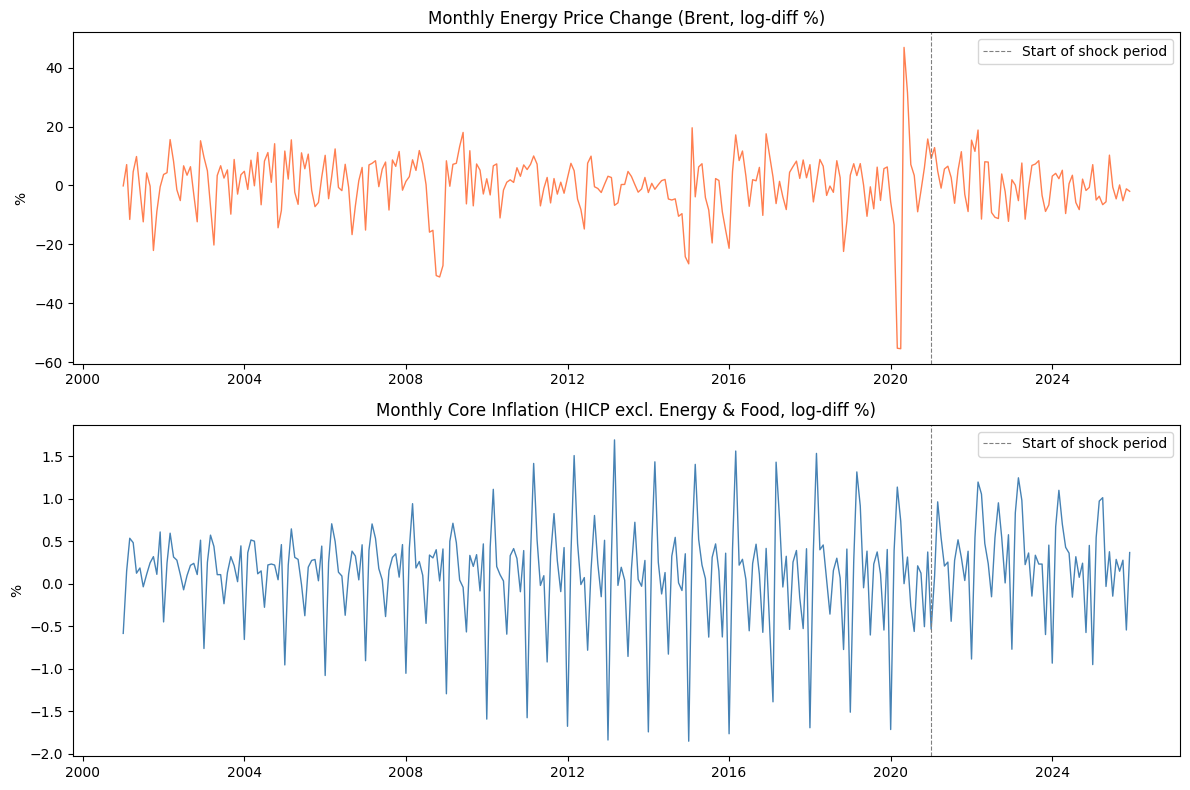

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df['d_brent'], color='coral', linewidth=1)
axes[0].axvline(pd.Timestamp('2021-01'), color='gray', linestyle='--', linewidth=0.8, label='Start of shock period')
axes[0].set_title('Monthly Energy Price Change (Brent, log-diff %)')
axes[0].set_ylabel('%')
axes[0].legend()
axes[1].plot(df['d_core'], color='steelblue', linewidth=1)
axes[1].axvline(pd.Timestamp('2021-01'), color='gray', linestyle='--', linewidth=0.8, label='Start of shock period')
axes[1].set_title('Monthly Core Inflation (HICP excl. Energy & Food, log-diff %)')
axes[1].set_ylabel('%')
axes[1].legend()
axes[0].tick_params(labelbottom=True)
plt.tight_layout()
plt.savefig('timeseries.png', dpi=150)
plt.show()

The Brent crude oil price (top) shows high volatility throughout the entire sample, with a sharp drop in early 2020 reflecting the COVID-19 shock. Core inflation (bottom) is a lot smoother, with a persistent upward shift starting in 2021 that reduces toward the end of the sample. This difference already suggests a limited pass-through.

To investigate the lag structure, we compute the cross-correlation function (CCF) between energy price changes and core inflation for both periods separately.The CCF measures the correlation between the Brent log-difference at time $t$ and core inflation at time $t+k$, for lags $k=0,1,2,3$. A significant bar at lag $k$ would suggest that energy price movements predict core inflation $k$ months later. The red dashed lines indicate the $95\%$ confidence band, correlations exceeding these bounds we consider statistically significant.

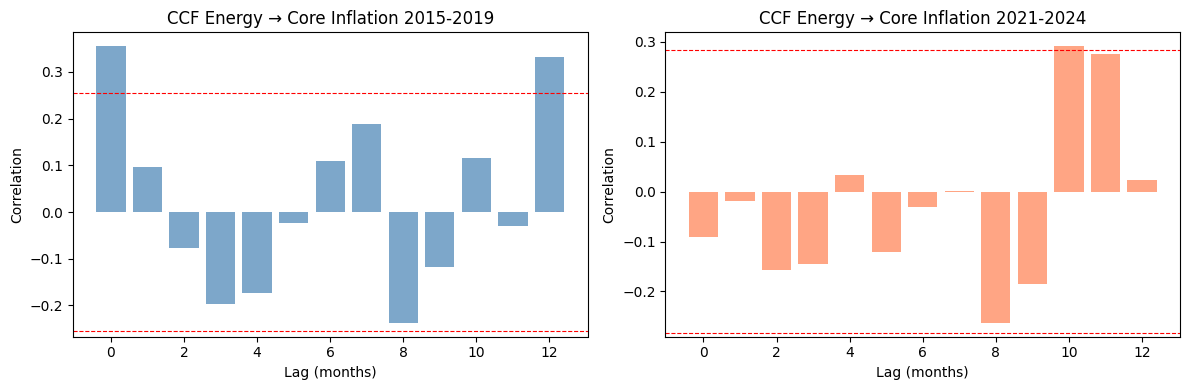

In [20]:
ccf_pre_vals = sm_ccf(pre['d_brent'].dropna(), pre['d_core'].dropna(), nlags=13, alpha=0.05)
ccf_post_vals = sm_ccf(post['d_brent'].dropna(), post['d_core'].dropna(), nlags=13, alpha=0.05)
ccf_pre, ccf_pre_ci = ccf_pre_vals[0], ccf_pre_vals[1]
ccf_post, ccf_post_ci = ccf_post_vals[0], ccf_post_vals[1]

#confidence band width (symmetric around 0)
ci_pre_band = ccf_pre_ci[:, 1] - ccf_pre
ci_post_band = ccf_post_ci[:, 1] - ccf_post

lags = range(0, 13)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(lags, ccf_pre[:13], color='steelblue', alpha=0.7)
axes[0].axhline( ci_pre_band[:13].mean(), color='red', linestyle='--', linewidth=0.8)
axes[0].axhline(-ci_pre_band[:13].mean(), color='red', linestyle='--', linewidth=0.8)
axes[0].set_title('CCF Energy → Core Inflation 2015-2019')
axes[0].set_xlabel('Lag (months)')
axes[0].set_ylabel('Correlation')
axes[1].bar(lags, ccf_post[:13], color='coral', alpha=0.7)
axes[1].axhline( ci_post_band[:13].mean(), color='red', linestyle='--', linewidth=0.8)
axes[1].axhline(-ci_post_band[:13].mean(), color='red', linestyle='--', linewidth=0.8)
axes[1].set_title('CCF Energy → Core Inflation 2021-2024')
axes[1].set_xlabel('Lag (months)')
axes[1].set_ylabel('Correlation')
plt.tight_layout()
plt.savefig('ccf_comparison.png', dpi=150)
plt.show()

We focus on lags 0–3 to capture short-term responses of core inflation to energy price changes. While pass-through may occur over longer periods, these longer lags are harder to interpret due to overlapping effects and the limited sample size. In the first period (2015-2019), only lag 0 exceeds the confidence band, showing a small but statistically significant contemporaneous correlation between energy price changes and core inflation. No delayed pass-through can be seen. In the second period (2021-2024), no lag is significant within the $0-3$ range, suggesting that even that immediate relationship disappeared.

We estimate a simple bivariate OLS regression for each period separately, regressing core inflation on Brent price changes: $$\Delta \log HICP_t = \alpha + \beta \Delta \log Brent_{t-k} + \varepsilon_t \ \ \ \  k = 0, 1, 2, 3$$ Each lag is estimated as a separate regression. The coefficient $\beta$ represents the percentage point change in core inflation for a one percent increase in the Brent price $k$ months earlier. A significant $\beta$ at lag $k$ indicates a delayed pass-through of that length.

In [21]:
for period, core_var, name in [
    (pre,      'd_core', '2015-2019'),
    (post, 'd_core', '2021-2024')]:
    print(f'\n{name}:')
    for lag in [0, 1, 2, 3]:
        X = sm.add_constant(period['d_brent'].shift(lag).dropna())
        y = period[core_var].loc[X.index]
        model = sm.OLS(y, X).fit()
        print(f'Lag {lag}: Koeff={model.params.iloc[1]:.4f}, '
              f'p={model.pvalues.iloc[1]:.3f}, R\u00b2={model.rsquared:.3f}')


2015-2019:
Lag 0: Koeff=0.0279, p=0.006, R²=0.126
Lag 1: Koeff=0.0058, p=0.557, R²=0.006
Lag 2: Koeff=-0.0005, p=0.957, R²=0.000
Lag 3: Koeff=-0.0139, p=0.155, R²=0.037

2021-2024:
Lag 0: Koeff=-0.0061, p=0.543, R²=0.008
Lag 1: Koeff=0.0141, p=0.146, R²=0.046
Lag 2: Koeff=0.0158, p=0.107, R²=0.058
Lag 3: Koeff=-0.0075, p=0.446, R²=0.014


The results confirm the CCF findings. In the pre-shock period, only lag 0 is statistically significant ($\beta=0.0279$, $p=0.006$, $R^2=0.126$), indicating a small contemporaneous effect: a $10\%$ increase in the Brent price is associated with approximately $0.28\%$ higher core inflation in the same month. No delayed pass-through is detectable at lags $1-3$. In the post-shock period, none of these lags is significant, and the coefficients are small. The overall explanatory power is very low in both periods.

To test whether the pass-through coefficient changed significantly between the two periods, we estimate a single interaction model over the full sample (2015–2019 and 2021–2024):
$$\Delta \log HICP_t = \alpha + \beta_1 \Delta \log Brent_t + \beta_2 Post_t + \beta_3 (Post_t \times \Delta \log Brent_t) + \varepsilon_t$$
where $Post_t$ is a dummy variable equal to $1$ from January 2021 onward. The coefficient $\beta_3$ on the interaction term tests whether the pass-through differs between periods. OLS residuals in macroeconomic time series are often heteroscedastic and serially correlated, which would invalidate standard errors. We therefore use Newey-West (HAC) standard errors, which correct for both. HC3, which only accounts for heteroscedasticity, is also reported to show whether serial correlation makes a difference.

In [22]:
df_full = df['2015-01':'2024-12'].dropna().copy()
df_full['post'] = (df_full.index >= '2021-01').astype(int)
df_full['d_brent_lag0'] = df_full['d_brent']
df_full['interaction'] = df_full['post'] * df_full['d_brent_lag0']
df_full = df_full.dropna()
X = sm.add_constant(df_full[['d_brent_lag0', 'post', 'interaction']])
y = df_full['d_core']
model_hc3 = sm.OLS(y, X).fit(cov_type = 'HC3')
model_nw = sm.OLS(y, X).fit(cov_type = 'HAC', cov_kwds = {'maxlags': 4}) 
#maxlags = 4 by the rule of thumb T^(1/3) = 4.9 for n = 119

print('\nInteraction Model: HC3 (heteroscedasticity robust):')
print(model_hc3.summary())
print('\nInteraction Model: Newey-West HAC (heteroscedasticity and serial correlation robust):')
print(model_nw.summary())


Interaction Model: HC3 (heteroscedasticity robust):
                            OLS Regression Results                            
Dep. Variable:                 d_core   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.291
Date:                Tue, 31 Mar 2026   Prob (F-statistic):              0.281
Time:                        06:05:33   Log-Likelihood:                -118.33
No. Observations:                 119   AIC:                             244.7
Df Residuals:                     115   BIC:                             255.8
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

The comparison shows that serial correlation is not negligible here: the post-period dummy goes from borderline insignificant under HC3 (p=0.065) to clearly significant under Newey-West (p=0.012), while the interaction term stays insignificant under both specifications. Newey-West is therefore the appropriate specification.

The interaction model confirms the two main findings of the analysis. First, core inflation was significantly higher in the post-2021 period than in the pre-shock baseline ($\beta=0.218$, $p=0.012$ under Newey-West), reflecting the inflationary episode following the pandemic and the energy crisis. Second, the interaction term is not significant under either specification, meaning that the pass-through coefficient from energy prices to core inflation did not change detectably between the two periods.

The results suggest that the surge in euro area core inflation after 2021 was not driven by a stronger direct transmission from energy prices. Even in the pre-shock period, there was only a small contemporaneous pass-through. The higher level of core inflation in 2021–2024 therefore points to other drivers, such as second-round effects, shifts in inflation expectations, supply chain disruptions, or wage growth, that fall outside the scope of this bivariate framework.

These findings align with the literature, which generally finds that energy prices have limited direct effects on core inflation. The persistence of the inflation episode after 2021 likely reflects more structural factors. A simple extension of this analysis would be to include additional variables, such as inflation expectations or wage growth, to better explain the dynamics of the post-shock period.